In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.cluster import KMeans

In [12]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [13]:
dataset= pd.read_csv('Cleaned Mental Health Data.csv')

In [14]:
df = scale.fit_transform(dataset)

In [16]:
print(df)

[[ 0.41951281  0.46039745  0.         ...  0.46673173 -0.0965598
  -0.99620414]
 [ 1.1344998   0.46039745  0.         ... -0.54833819 -0.0965598
  -0.99620414]
 [ 1.1344998   0.46039745  0.         ...  0.46673173 -0.0965598
   0.61913888]
 ...
 [-0.29547417  0.46039745  0.         ...  0.46673173  2.07680214
   1.42681038]
 [-0.29547417 -2.17203636  0.         ... -1.56340812 -0.0965598
   0.61913888]
 [-0.29547417  0.46039745  0.         ...  0.46673173 -0.0965598
  -0.18853263]]


In [17]:
dataset_scaled = pd.DataFrame(df, columns=dataset.columns)

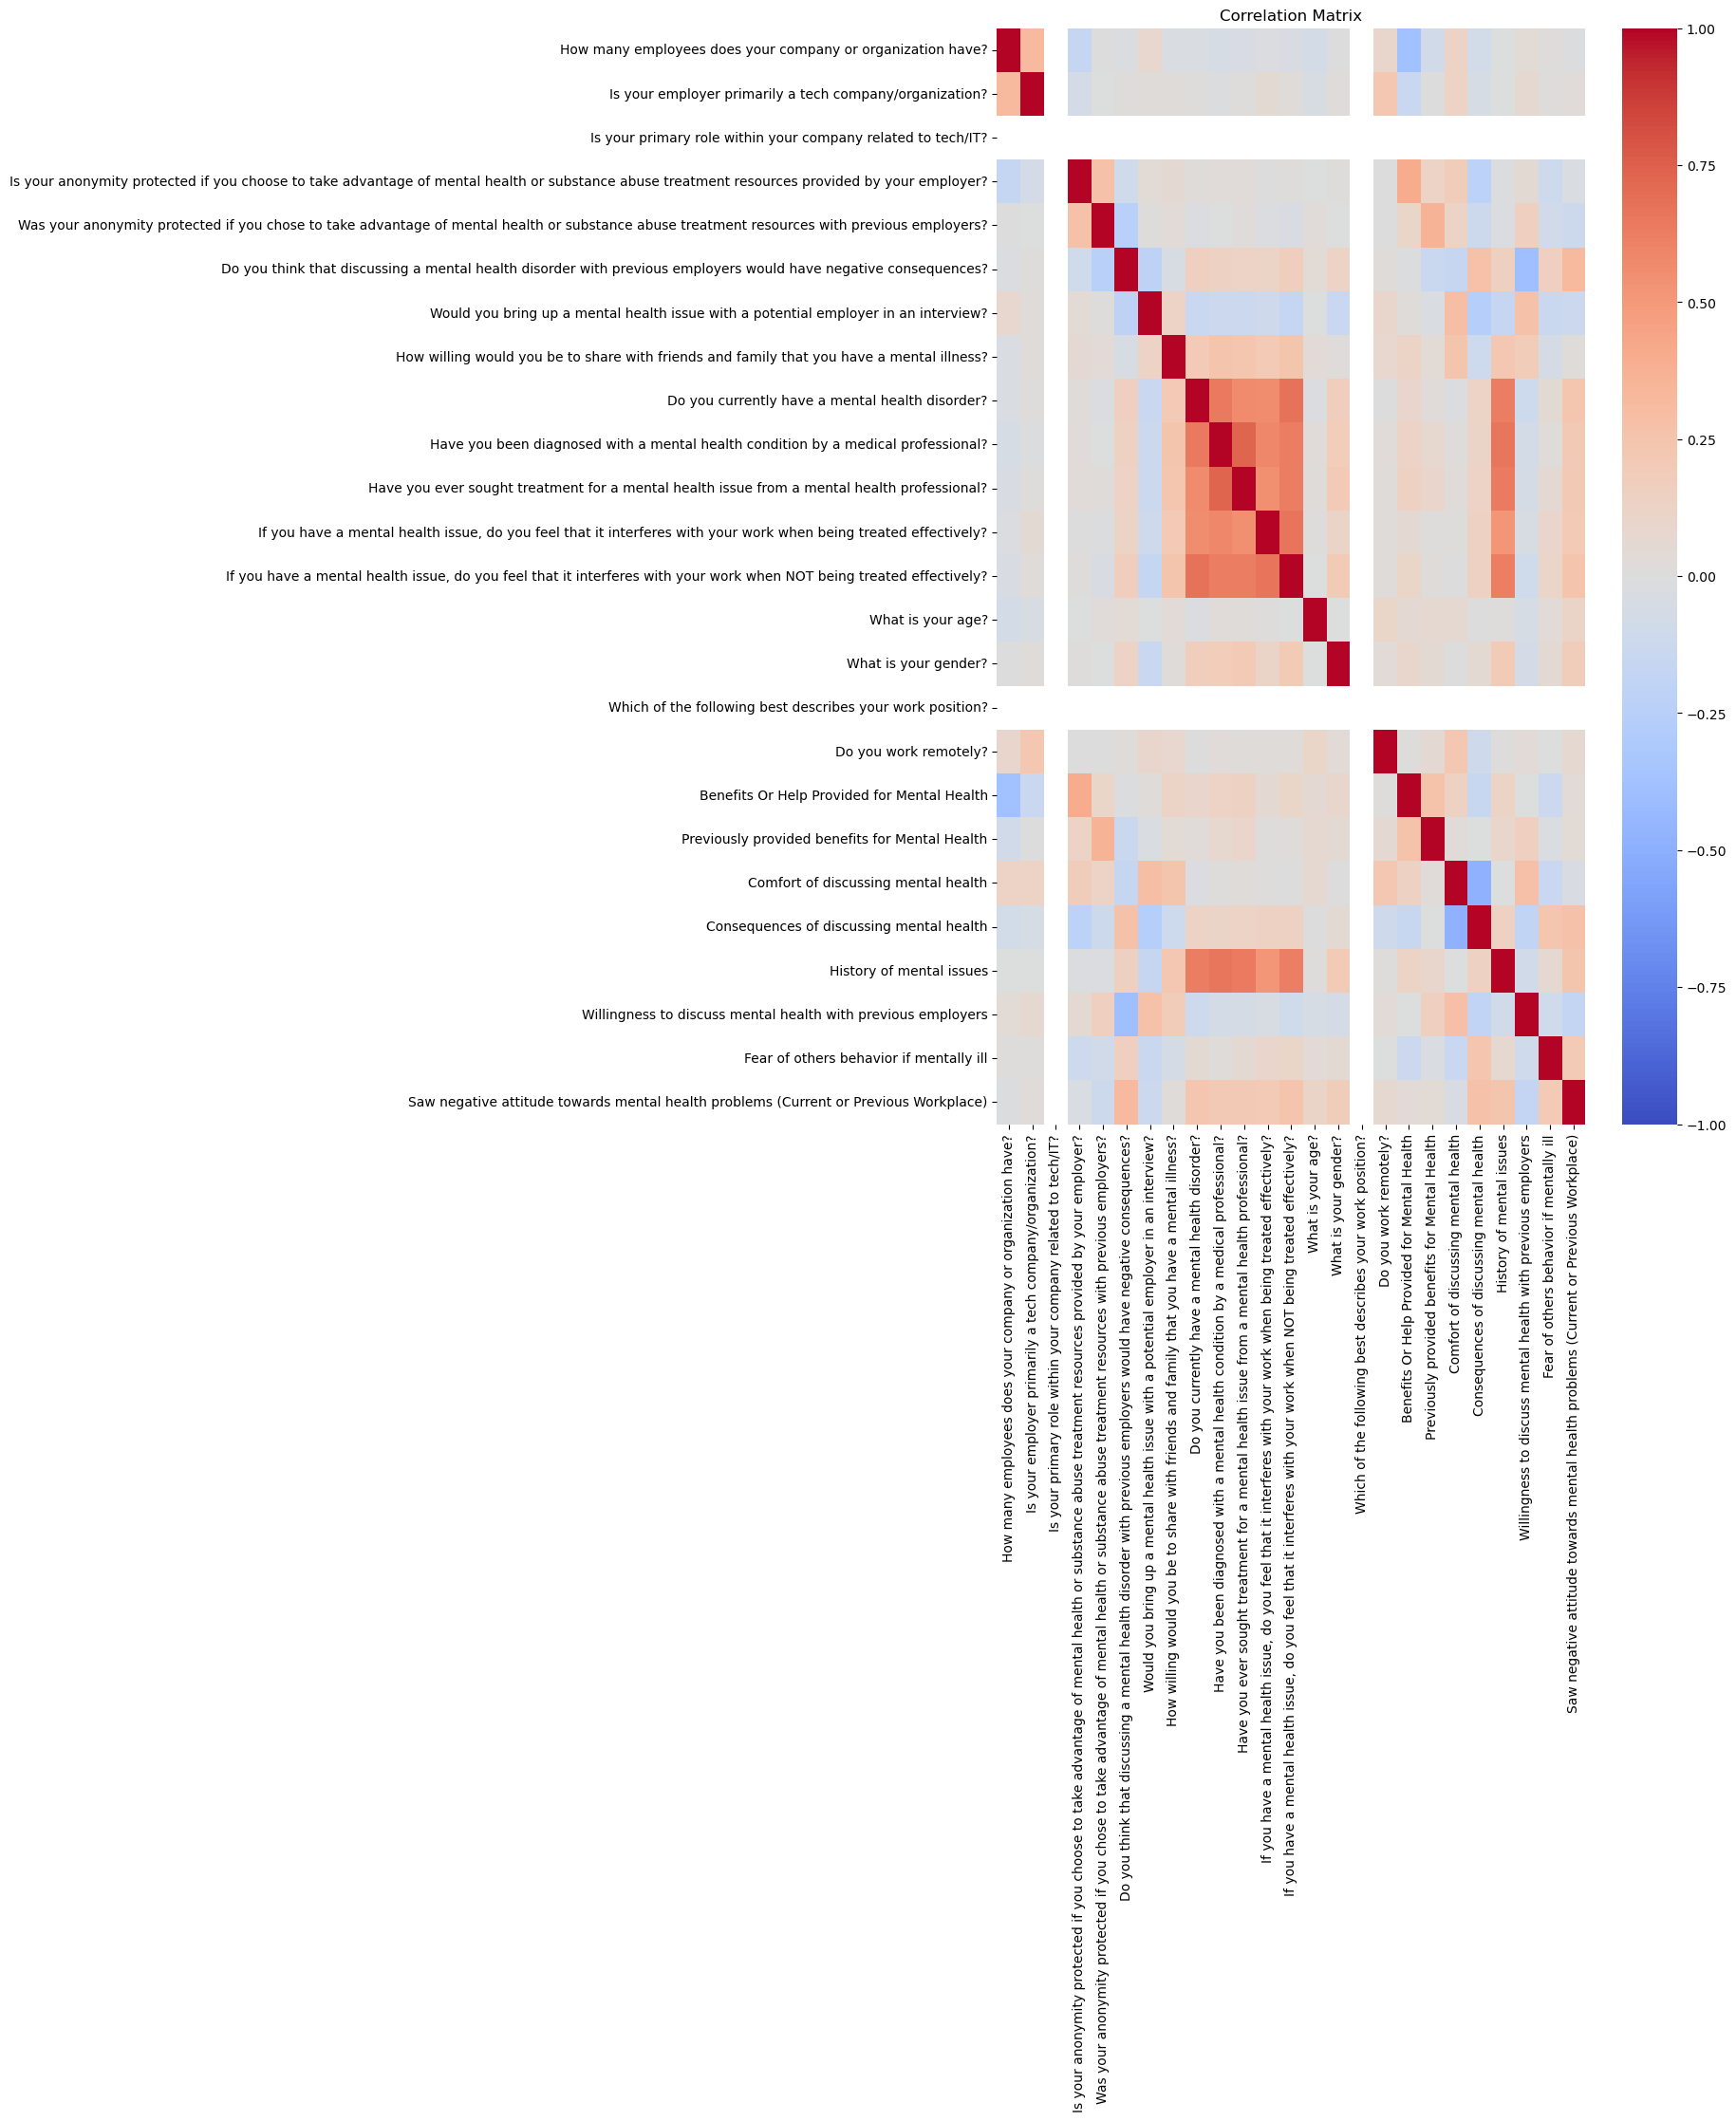

In [18]:
corr_mtrx = dataset_scaled.corr()
plt.figure(figsize= (10, 15))
sns.heatmap(corr_mtrx, annot= False, cmap= 'coolwarm', vmin= -1, vmax= 1 )
plt.title('Correlation Matrix')
plt.show()

In [19]:
# 1. Fit K-Means (Assuming 2 clusters for this example)

kmeans = KMeans(n_clusters=2, random_state=42)
dataset_scaled['Cluster'] = kmeans.fit_predict(dataset_scaled)

# 2. Interpret the clusters by calculating the mean of each column
cluster_profiles = dataset_scaled.groupby('Cluster').mean()
cluster_profiles.T

Cluster,0,1
How many employees does your company or organization have?,0.067118,-0.053814
Is your employer primarily a tech company/organization?,0.009838,-0.007888
Is your primary role within your company related to tech/IT?,0.000000,0.000000
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,-0.028081,0.022515
Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,-0.007980,0.006398
Do you think that discussing a mental health disorder with previous employers would have negative consequences?,-0.203091,0.162834
Would you bring up a mental health issue with a potential employer in an interview?,0.217198,-0.174145
How willing would you be to share with friends and family that you have a mental illness?,-0.288288,0.231144
Do you currently have a mental health disorder?,-0.804446,0.644987
Have you been diagnosed with a mental health condition by a medical professional?,-0.938020,0.752085


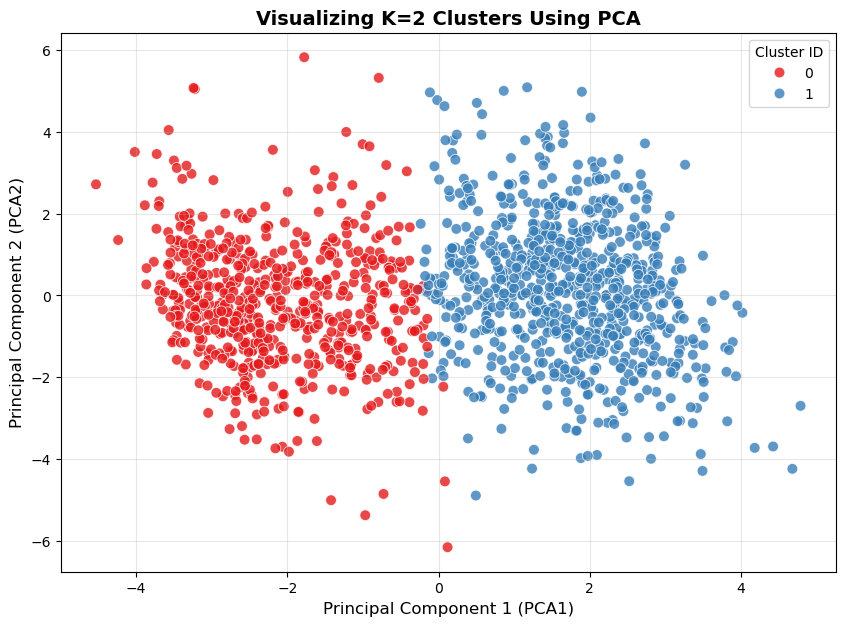

In [20]:
from sklearn.decomposition import PCA
# 1. Separate your features from the 'Cluster' column
# This prevents PCA from accidentally using the cluster labels to plot
features = dataset_scaled.drop(columns=["Cluster"], errors="ignore")

# 2. Compress the 25 columns into 2 dimensions
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(features)

# 3. Add the PCA coordinates back to your dataset for plotting
dataset_scaled["PCA1"] = pca_results[:, 0]
dataset_scaled["PCA2"] = pca_results[:, 1]

# 4. Plot the 2D Scatter Plot
plt.figure(figsize=(10, 7))

# 'hue' colors the dots by your 2 clusters
sns.scatterplot(
    data=dataset_scaled,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",  # High-contrast colors for 2 clusters
    s=60,
    alpha=0.8,
)

plt.title("Visualizing K=2 Clusters Using PCA", fontsize=14, weight="bold")
plt.xlabel("Principal Component 1 (PCA1)", fontsize=12)
plt.ylabel("Principal Component 2 (PCA2)", fontsize=12)
plt.legend(title="Cluster ID", loc="best")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Clean up the dataset by removing the temporary PCA columns
dataset_scaled = dataset_scaled.drop(columns=["PCA1", "PCA2"])

In [21]:
from sklearn.metrics import silhouette_score
k_range = range(2, 15)
silhouette_scores =[]
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(dataset_scaled)

    # Calculate the average silhouette score for this K
    score = silhouette_score(dataset_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, the average Silhouette Score is: {score:.2f}")

For K = 2, the average Silhouette Score is: 0.17
For K = 3, the average Silhouette Score is: 0.13
For K = 4, the average Silhouette Score is: 0.08
For K = 5, the average Silhouette Score is: 0.07
For K = 6, the average Silhouette Score is: 0.07
For K = 7, the average Silhouette Score is: 0.07
For K = 8, the average Silhouette Score is: 0.06
For K = 9, the average Silhouette Score is: 0.06
For K = 10, the average Silhouette Score is: 0.06
For K = 11, the average Silhouette Score is: 0.06
For K = 12, the average Silhouette Score is: 0.06
For K = 13, the average Silhouette Score is: 0.06
For K = 14, the average Silhouette Score is: 0.07


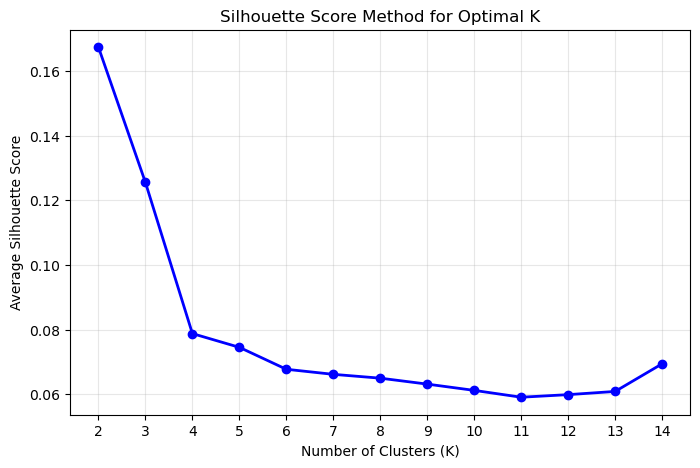

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='b', linewidth=2)
plt.title("Silhouette Score Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

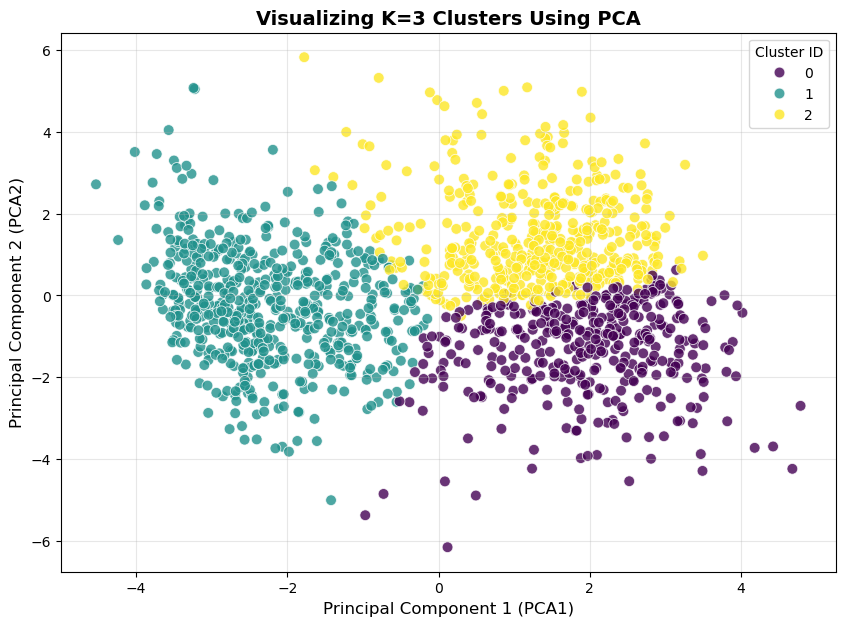

In [23]:
# 1. Run K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
dataset_scaled['Cluster'] = kmeans.fit_predict(dataset_scaled.drop(columns=['Cluster'], errors='ignore'))

# 2. Separate features for PCA compression
features = dataset_scaled.drop(columns=['Cluster'], errors='ignore')

# 3. Compress the 25 columns into 2 dimensions
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(features)

dataset_scaled['PCA1'] = pca_results[:, 0]
dataset_scaled['PCA2'] = pca_results[:, 1]

# 4. Plot the 3D data onto a 2D Scatter Plot
plt.figure(figsize=(10, 7))

# 'palette=viridis' or 'Set1' works great for showing 3 distinct groups
sns.scatterplot(
    data=dataset_scaled,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis', 
    s=60,
    alpha=0.8
)

plt.title("Visualizing K=3 Clusters Using PCA", fontsize=14, weight='bold')
plt.xlabel("Principal Component 1 (PCA1)", fontsize=12)
plt.ylabel("Principal Component 2 (PCA2)", fontsize=12)
plt.legend(title="Cluster ID", loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Clean up temporary PCA columns from your dataset
dataset_scaled = dataset_scaled.drop(columns=['PCA1', 'PCA2'])

In [25]:
dataset_scaled.head()

,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Would you bring up a mental health issue with a potential employer in an interview?,How willing would you be to share with friends and family that you have a mental illness?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,...,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health,History of mental issues,Willingness to discuss mental health with previous employers,Fear of others behavior if mentally ill,Saw negative attitude towards mental health problems (Current or Previous Workplace),Cluster
0,0.419513,0.460397,0.0,-0.321399,-0.064858,-0.160164,0.845711,-0.087009,-1.174551,0.998591,...,-0.017457,-1.443466,-0.365210,0.612701,-1.215326,-0.217834,0.466732,-0.09656,-0.996204,1
1,1.134500,0.460397,0.0,1.668751,2.178282,-2.243772,-0.728066,-0.087009,1.103853,0.998591,...,-1.473557,1.390831,0.988693,0.612701,-1.215326,1.105030,-0.548338,-0.09656,-0.996204,2
2,1.134500,0.460397,0.0,-0.321399,-0.064858,-0.160164,2.419488,-0.087009,-1.174551,-1.001411,...,1.438643,-1.443466,-0.365210,-0.142130,0.122665,-0.879266,0.466732,-0.09656,0.619139,1
3,0.419513,0.460397,0.0,-0.321399,-0.064858,-0.160164,0.845711,-0.087009,1.103853,0.998591,...,-0.017457,-0.498700,-0.365210,0.612701,0.122665,-0.217834,0.466732,-0.09656,-0.188533,2
4,1.134500,-2.172036,0.0,-2.311550,-0.064858,-0.160164,-0.728066,-0.087009,1.103853,0.998591,...,-0.017457,0.446065,0.311742,-0.896960,1.460656,1.105030,-0.548338,-0.09656,1.426810,0


In [26]:
x = dataset['How many employees does your company or organization have?']
y= dataset['What is your age?']

<Axes: xlabel='How many employees does your company or organization have?', ylabel='What is your age?'>

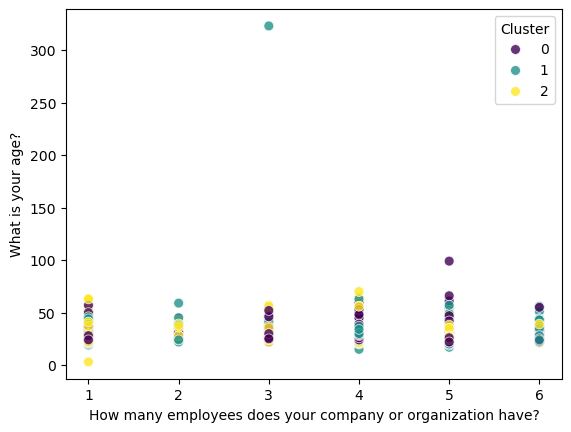

In [28]:
sns.scatterplot(
    data=dataset_scaled, 
    x= x, 
    y= y, 
    hue='Cluster', 
    palette='viridis', 
    s=50, 
    alpha=0.8
)

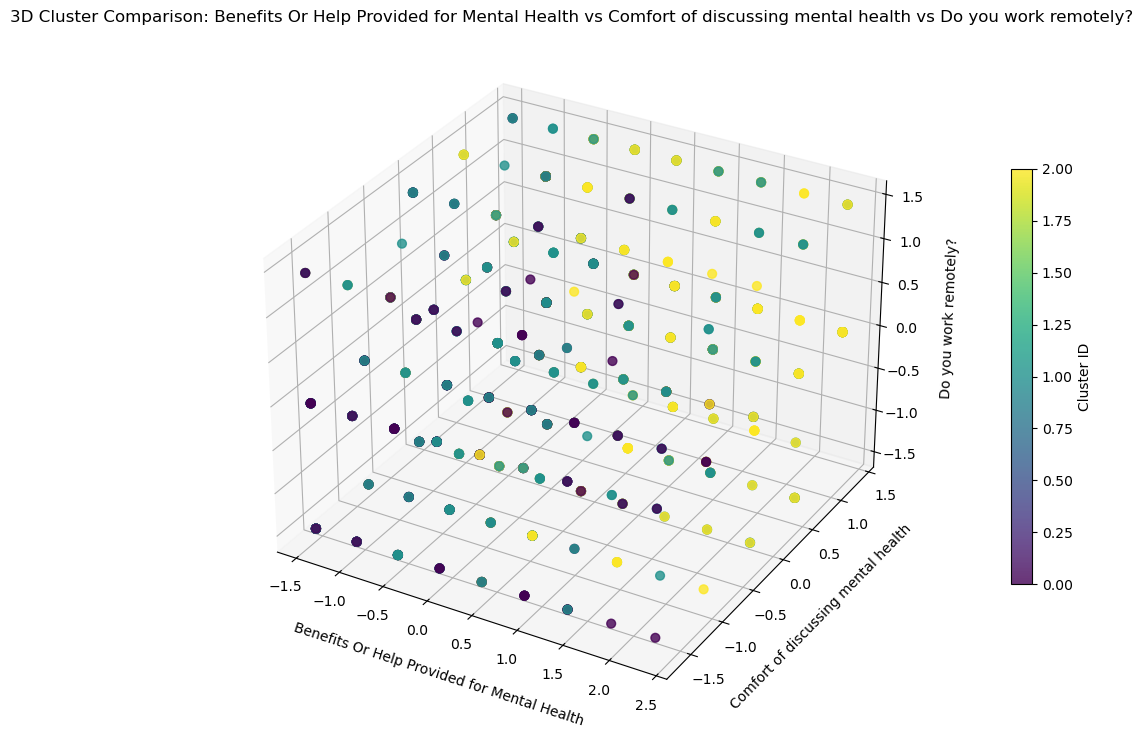

In [29]:
from mpl_toolkits.mplot3d import Axes3D

# Replace with your actual column names
col_x = 'Benefits Or Help Provided for Mental Health'
col_y = 'Comfort of discussing mental health'
col_z = 'Do you work remotely?'

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using 3 specific columns, colored by Cluster
scatter = ax.scatter(
    dataset_scaled[col_x], 
    dataset_scaled[col_y], 
    dataset_scaled[col_z], 
    c=dataset_scaled['Cluster'], 
    cmap='viridis', 
    s=40, 
    alpha=0.8
)

# Label axes based on columns
ax.set_xlabel(col_x, labelpad=10)
ax.set_ylabel(col_y, labelpad=10)
ax.set_zlabel(col_z, labelpad=10)
ax.set_title(f'3D Cluster Comparison: {col_x} vs {col_y} vs {col_z}')

# Add color bar legend
colorbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
colorbar.set_label('Cluster ID')

plt.show()

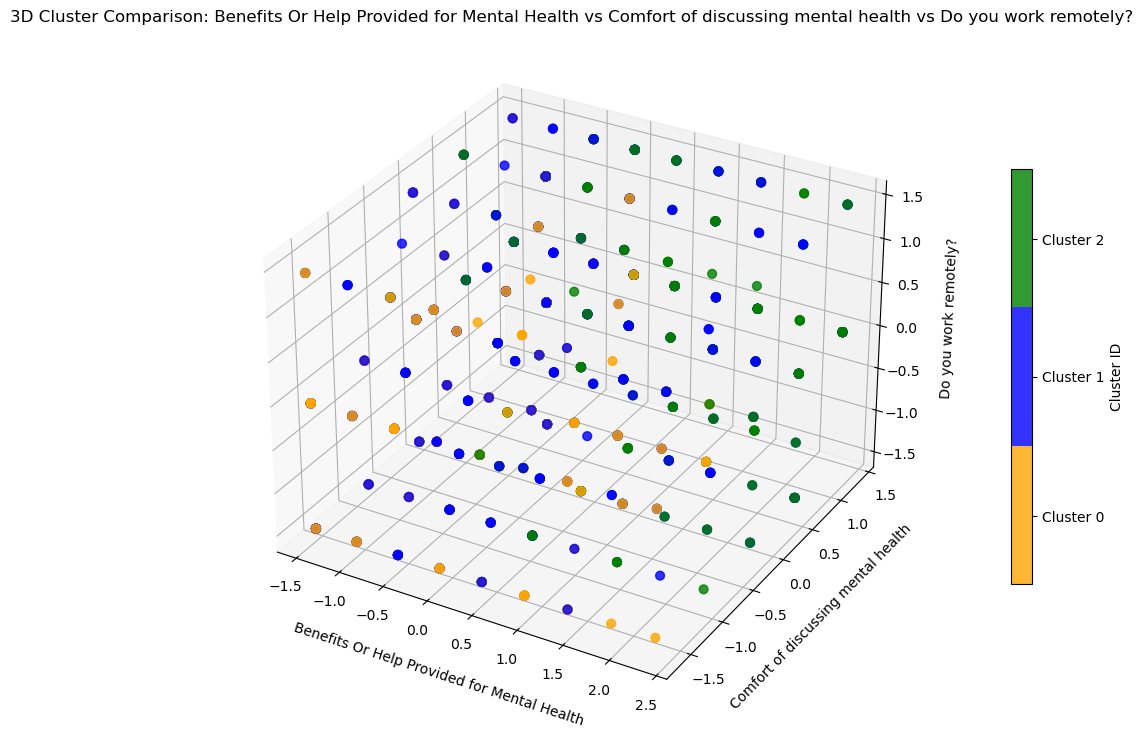

In [31]:
from matplotlib.colors import ListedColormap

col_x = "Benefits Or Help Provided for Mental Health"
col_y = "Comfort of discussing mental health"
col_z = "Do you work remotely?"

# --- CHOOSE YOUR CUSTOM COLORS HERE ---
# Example: Soft Blue for Cluster 0, Vibrant Coral for Cluster 1, Deep Purple for Cluster 2
my_colors = ["orange", "blue", "green"]
custom_cmap = ListedColormap(my_colors)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot using your custom colormap
scatter = ax.scatter(
    dataset_scaled[col_x],
    dataset_scaled[col_y],
    dataset_scaled[col_z],
    c=dataset_scaled["Cluster"],
    cmap=custom_cmap,  # <-- Using your custom colors here
    s=40,
    alpha=0.8,
)

# Label axes based on columns
ax.set_xlabel(col_x, labelpad=10)
ax.set_ylabel(col_y, labelpad=10)
ax.set_zlabel(col_z, labelpad=10)
ax.set_title(f"3D Cluster Comparison: {col_x} vs {col_y} vs {col_z}")

# Add color bar legend
colorbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
colorbar.set_label("Cluster ID")

# Optional: This forces the colorbar to only show 0, 1, and 2 cleanly
colorbar.set_ticks([0.33, 1.0, 1.66])
colorbar.set_ticklabels(["Cluster 0", "Cluster 1", "Cluster 2"])

plt.show()

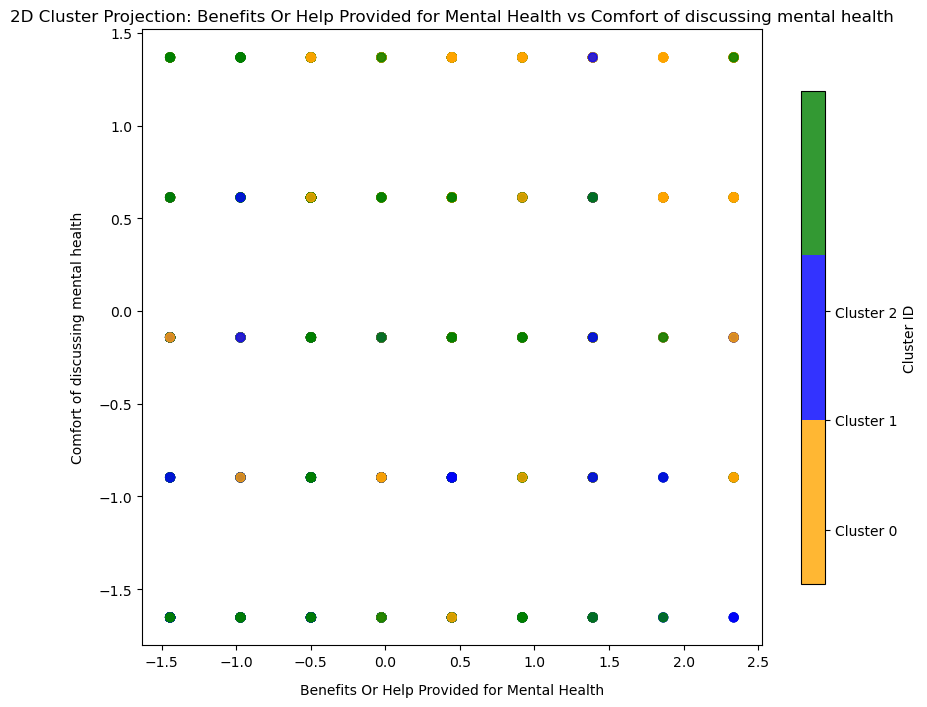

In [36]:
import matplotlib.pyplot as plt

# Using the same columns and color setup as your original code
fig, ax = plt.subplots(figsize=(10, 8))

# Standard 2D scatter plot
scatter = ax.scatter(
    dataset_scaled[col_x],
    dataset_scaled[col_y],
    c=dataset_scaled["Cluster"],
    cmap=custom_cmap,
    s=40,
    alpha=0.8,
)

# 2D Labels
ax.set_xlabel(col_x, labelpad=10)
ax.set_ylabel(col_y, labelpad=10)
ax.set_title(f"2D Cluster Projection: {col_x} vs {col_y}")

# Clean 2D Colorbar Legend
colorbar = fig.colorbar(scatter, ax=ax, pad=0.05, shrink=0.8)
colorbar.set_label("Cluster ID")
colorbar.set_ticks([0.33, 1.0, 1.66])
colorbar.set_ticklabels(["Cluster 0", "Cluster 1", "Cluster 2"])

plt.show()


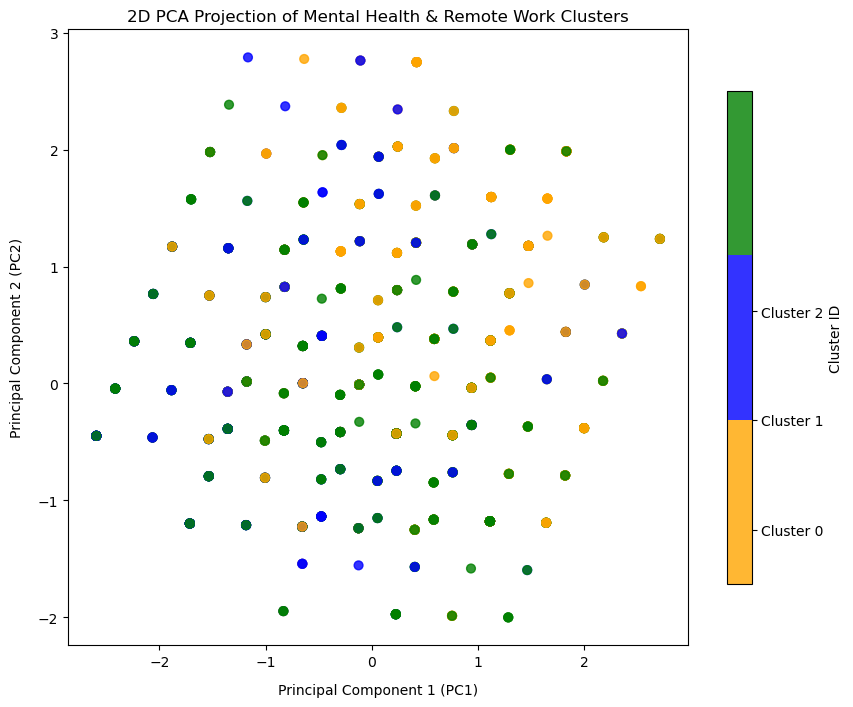

Total explained variance: 75.50%


In [37]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# 1. Extract just the 3 features used in your graph
features_to_project = dataset_scaled[[col_x, col_y, col_z]]

# 2. Initialize and run PCA to reduce 3D down to 2D
pca = PCA(n_components=2, random_state=42)
pca_transformed = pca.fit_transform(features_to_project)

# Create a clean DataFrame with the new components
pca_df = pd.DataFrame(data=pca_transformed, columns=["PC1", "PC2"])
pca_df["Cluster"] = dataset_scaled["Cluster"].values

# 3. Create the 2D PCA Plot
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap=custom_cmap,  # Keeps your orange, blue, green theme
    s=40,
    alpha=0.8,
)

# Axis labels representing the new condensed dimensions
ax.set_xlabel("Principal Component 1 (PC1)", labelpad=10)
ax.set_ylabel("Principal Component 2 (PC2)", labelpad=10)
ax.set_title("2D PCA Projection of Mental Health & Remote Work Clusters")

# Keep your identical colorbar formatting
colorbar = fig.colorbar(scatter, ax=ax, pad=0.05, shrink=0.8)
colorbar.set_label("Cluster ID")
colorbar.set_ticks([0.33, 1.0, 1.66])
colorbar.set_ticklabels(["Cluster 0", "Cluster 1", "Cluster 2"])

plt.show()

# 4. Print how much information was successfully retained
print(
    f"Total explained variance: {sum(pca.explained_variance_ratio_) * 100:.2f}%"
)

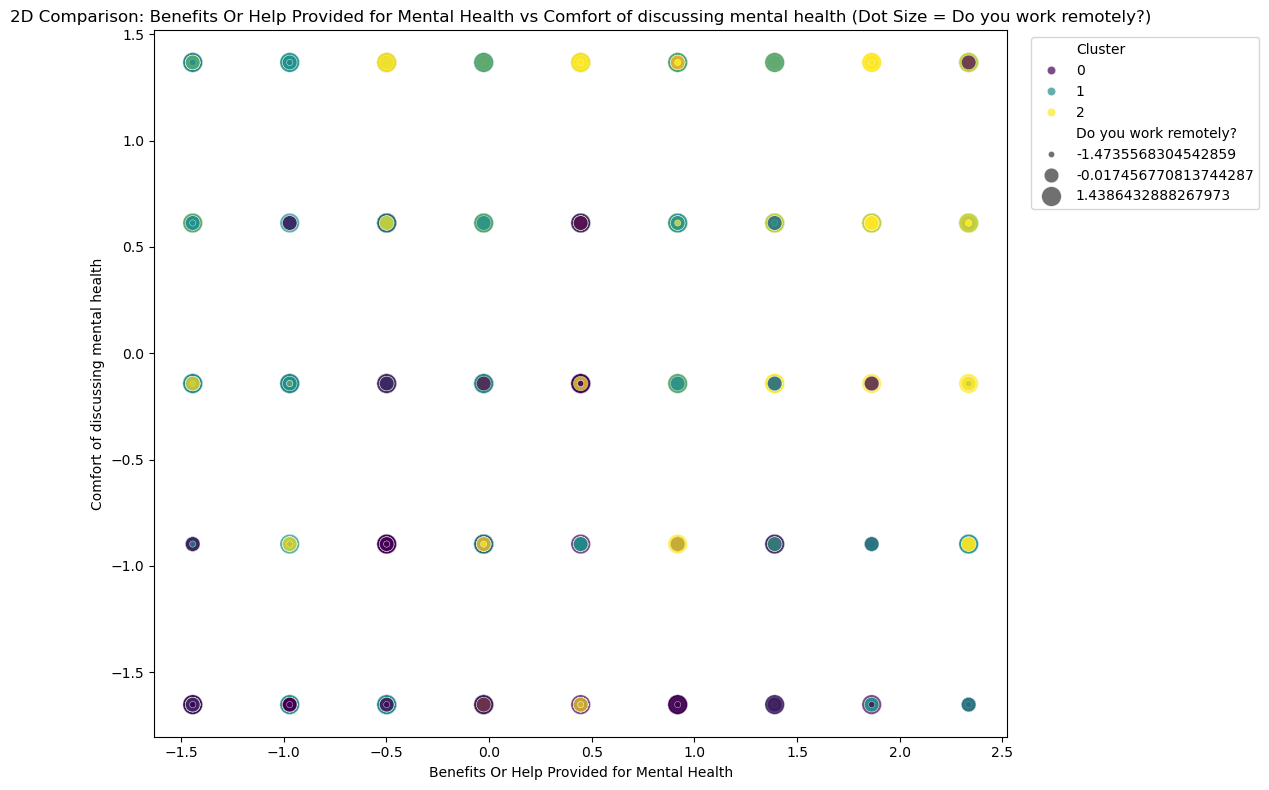

In [32]:
col_x = 'Benefits Or Help Provided for Mental Health'  # Goes on X-axis
col_y = 'Comfort of discussing mental health'  # Goes on Y-axis
col_size = 'Do you work remotely?'  # Changes size of the dots

plt.figure(figsize=(12, 8))

# 'hue' handles clusters, 'size' handles the 3rd column
sns.scatterplot(
    data=dataset_scaled, 
    x=col_x, 
    y=col_y, 
    hue='Cluster', 
    size=col_size,
    sizes=(20, 200),  # Sets minimum and maximum dot sizes
    palette='viridis', 
    alpha=0.7
)

plt.title(f'2D Comparison: {col_x} vs {col_y} (Dot Size = {col_size})')
plt.xlabel(col_x)
plt.ylabel(col_y)

# Move the legend outside so it doesn't cover your data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [34]:
# Calculate the average score for each column inside each cluster
profiles = dataset_scaled.groupby('Cluster').mean()

# Transpose the table so columns are rows, making it much easier to read
profiles.T


Cluster,0,1,2
How many employees does your company or organization have?,0.002437,0.062019,-0.082232
Is your employer primarily a tech company/organization?,0.000429,-0.012548,0.015886
Is your primary role within your company related to tech/IT?,0.000000,0.000000,0.000000
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,-0.342799,-0.027937,0.315798
Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,-0.450775,0.011181,0.353271
Do you think that discussing a mental health disorder with previous employers would have negative consequences?,0.696803,-0.199011,-0.310952
Would you bring up a mental health issue with a potential employer in an interview?,-0.499615,0.205530,0.141653
How willing would you be to share with friends and family that you have a mental illness?,-0.096764,-0.320727,0.493915
Do you currently have a mental health disorder?,0.665934,-0.855960,0.564231
Have you been diagnosed with a mental health condition by a medical professional?,0.654504,-0.967513,0.717889


In [35]:
# 1. Fit K-Means (Assuming 4 clusters for this example)
kmeans = KMeans(n_clusters=4, random_state=42)
dataset_scaled['Cluster'] = kmeans.fit_predict(dataset_scaled)

# 2. Interpret the clusters by calculating the mean of each column
cluster_profiles = dataset_scaled.groupby('Cluster').mean()
cluster_profiles.T

Cluster,0,1,2,3
How many employees does your company or organization have?,-0.090055,-0.158562,-0.003521,0.264271
Is your employer primarily a tech company/organization?,0.008956,-0.211713,-0.000278,0.170588
Is your primary role within your company related to tech/IT?,0.000000,0.000000,0.000000,0.000000
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,0.325732,-0.137910,-0.337984,0.043766
Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,0.369782,-0.120539,-0.438715,0.079197
Do you think that discussing a mental health disorder with previous employers would have negative consequences?,-0.308662,0.135383,0.690642,-0.453271
Would you bring up a mental health issue with a potential employer in an interview?,0.120161,-0.382058,-0.491999,0.706140
How willing would you be to share with friends and family that you have a mental illness?,0.482767,-0.704674,-0.081969,0.035060
Do you currently have a mental health disorder?,0.581190,-0.770578,0.692474,-0.895847
Have you been diagnosed with a mental health condition by a medical professional?,0.735784,-0.930489,0.687479,-0.964714


In [38]:
dataset_scaled.to_csv('Scaled Data.csv')